# Scribble Evaluation Notebook
Load a scribble from a Google Drive or local path, generate conditioned photos,
compute MMD vs target distribution, and check CLIP softmax gender scores.

## 1. Setup

In [1]:
import os, sys, json, gc
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch
from pathlib import Path
from PIL import Image
from IPython.display import display
from huggingface_hub import login
from google.colab import userdata
import wandb



hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "SD-add-vis-and-table"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"✅ Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f"/content/{repo_name}"
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    print(f"\n✅ Repo ready. Branch: {branch}")
    print(f"📁 Python path: {repo_path}")

repo_path = f"/content/{repo_name}/SD_cond_SD_controlnet"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

wandb_token = userdata.get('WANDB')
if wandb_token:
    wandb.login(key=wandb_token)
else:
    wandb.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.3 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5490, done.
remote: Counting objects: 100% (448/448), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 5490 (delta 385), reused 346 (delta 308), pack-reused 5042 (from 1)
Receiving objects: 100% (5490/5490), 1.07 GiB | 40.65 MiB/s, done.
Resolving deltas: 100% (1430/1430), done.
Branch 'SD-add-vis-and-table' set up to track remote branch 'SD-add-vis-and-table' from 'origin'.
Switched to a new branch 'SD-add-vis-and-table'

✅ Repo ready. Branch: SD-add-vis-and-table
📁 Python path: /content/conditional-matching-paper


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ori-meidler (conditional-matching) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
import random

GLOBAL_SEED = 8   # using the optimization seed

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[Seed] All random seeds set to {seed}")

set_global_seed(GLOBAL_SEED)

[Seed] All random seeds set to 8


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


#Example

### 2. Load Scribble

In [4]:
from google.colab import drive
drive.mount('/content/drive')

RUNS_ROOT        = "/content/drive/MyDrive/conditional-matching/runs"
CONTROLNET_SCALE = 0.5
N_EVAL           = 250
N_TARGETS        = 250
EVAL_PROMPT      = "a superrealistic professional photograph of"
MAN_PROMPT       = "a superrealistic portrait photograph of a man, studio lighting"
WOMAN_PROMPT     = "a superrealistic portrait photograph of a woman, studio lighting"
n_half           = N_TARGETS // 2

JOB_IDS =[*range(44424926,44424936)]



Mounted at /content/drive


### 3. Load Models

In [5]:
from models     import load_models
from clip_utils import load_clip_model

architect, sprinter    = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print("✅ Models loaded.")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models loaded.


### 4. Helpers

In [6]:

from generation    import generate_and_store_cs
from clip_utils    import encode_images_clip
from visualization import plot_row
from run_dps       import compute_clip_softmax
from metrics       import compute_mmd

def pil_to_tensor(pil_list):
    return torch.cat(
        [TF.to_tensor(img).unsqueeze(0) for img in pil_list], dim=0
    ).to(next(clip_model.parameters()).device)

def generate_eval_photos(scribble_pil, n=N_EVAL, seed=None):
    sprinter.vae.to(dtype=torch.float16)

    generator = None
    if seed is not None:
        generator = torch.Generator(device=sprinter.device).manual_seed(seed)

    photos = []
    with torch.no_grad():
        for start in range(0, n, 2):
            bs = min(2, n - start)
            result = sprinter(
                prompt=[EVAL_PROMPT] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type="pil",
                generator=generator, # This now safely passes None if no seed is provided
            )
            photos.extend(result.images)

    sprinter.vae.to(dtype=torch.float32)
    return photos

def summarize(vals):
    a = np.array([float(v) for v in vals if v is not None and not np.isnan(float(v))])
    return (a.mean(), a.std()) if len(a) > 0 else (np.nan, np.nan)

def fmt(mean, std, decimals=3):
    fs = f"{{:.{decimals}f}}"
    return f"{fs.format(mean)} ± {fs.format(std)}"



def generate_and_store_cs(pipe, prompt, cond_pil, num_samples, batch_size=2, cn_scale=0.5,seed=None):
    """generate_and_store but with configurable controlnet_conditioning_scale."""
    original_vae_dtype = pipe.vae.dtype
    pipe.vae.to(dtype=torch.float16)
    all_images, all_lats = [], []

    def latents_callback(p, step_index, timestep, cb_kwargs):
        if step_index == p.num_timesteps - 1:
            p._current_latents = cb_kwargs["latents"].detach().cpu().numpy()
        return cb_kwargs

    generator = None
    if seed is not None:
        generator = torch.Generator(device=pipe.device).manual_seed(seed)
    for i in range(0, num_samples, batch_size):
        curr   = min(batch_size, num_samples - i)
        result = pipe(
            prompt=[prompt] * curr,
            image=[cond_pil] * curr,
            num_inference_steps=2,
            guidance_scale=0.0,
            controlnet_conditioning_scale=cn_scale,
            callback_on_step_end=latents_callback,
            generator=generator,
        )
        all_images.extend(result.images)
        all_lats.append(pipe._current_latents.reshape(curr, -1))
        print(f"  Progress: {len(all_images)}/{num_samples}", end="\r")

    print()
    pipe.vae.to(dtype=original_vae_dtype)
    return all_images, np.vstack(all_lats)


def evaluate_distribution_mmd(latent, architect_vae, architect_image_processor,
                                sprinter, clip_model, clip_processor,
                                all_clip_embeddings,eval_prompt, n_eval=10, device="cuda",seed=None):
    """
    Decode latent -> scribble PIL -> generate n_eval sprinter photos
    -> encode to CLIP -> compute MMD vs target distribution.
    Returns (mmd_scalar, eval_photos_list, clip_embs)
    """
    from clip_utils import encode_images_clip
    from image_utils import latent_to_pil

    # 1. Decode architect latent to scribble PIL
    with torch.no_grad():
        scribble_pil = latent_to_pil(latent, architect_vae, architect_image_processor)

    # 2. Generate sprinter photos from scribble
    original_vae_dtype = sprinter.vae.dtype
    sprinter.vae.to(dtype=torch.float16)
    eval_photos = []
    gen_eval = torch.Generator(device=device).manual_seed(seed) if seed is not None else None
    with torch.no_grad():
        for start in range(0, n_eval, 2):
            bs = min(2, n_eval - start)
            result = sprinter(
                prompt=[eval_prompt] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2, guidance_scale=0.0,
                controlnet_conditioning_scale=0.8,
                output_type="pil", return_dict=True,
                generator=gen_eval
            )
            eval_photos.extend(result.images)
    sprinter.vae.to(dtype=original_vae_dtype)

    # 3. Encode photos to CLIP
    tensors = [TF.to_tensor(img).unsqueeze(0) for img in eval_photos]
    photo_tensor = torch.cat(tensors, dim=0).to(device)
    clip_model.to(device)
    with torch.no_grad():
        clip_embs = encode_images_clip(photo_tensor, clip_model, clip_processor)
    clip_model.to("cpu")

    # 4. MMD vs target
    mmd = compute_mmd(clip_embs, all_clip_embeddings).item()

    return mmd, eval_photos, clip_embs

## 5. Load Best Run Images and Visualize

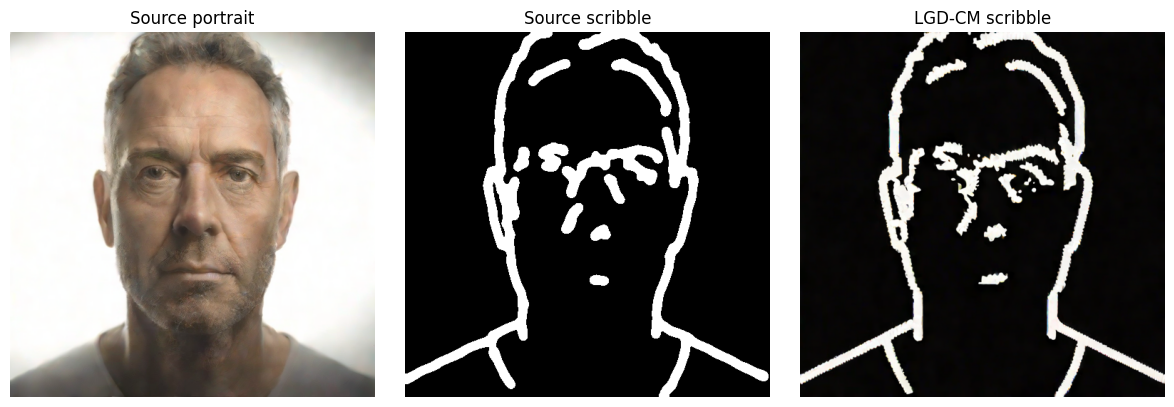

In [8]:

best_jid = 44424933
run_dir  = Path(RUNS_ROOT) / f"dps_main_{best_jid}"


lgd_img    = Image.open(run_dir / "final_scribble_lgd_cm.png")
source_scribble    = Image.open(run_dir / "scribble.png")
source_img = Image.open(run_dir / "source_portrait.png")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img,title in zip(
    axes,
    [source_img, source_scribble,lgd_img],
    ['Source portrait', 'Source scribble','LGD-CM scribble'],
):
    ax.imshow(img);
    ax.axis('off');
    ax.set_title(title)

plt.tight_layout(); display(fig); plt.close()

# ── Use LGD-CM scribble as scribble_pil_1, regular as scribble_pil_2 ──
scribble_pil_1 = lgd_img

## 6. Build Target Distribution


In [31]:

print(f"Building target distribution ({N_TARGETS} images)...")
with torch.no_grad():
    man_images,   _ = generate_and_store_cs(sprinter, MAN_PROMPT,   scribble_pil_1, n_half, batch_size=2, cn_scale=CONTROLNET_SCALE,seed=GLOBAL_SEED)
    woman_images, _ = generate_and_store_cs(sprinter, WOMAN_PROMPT, scribble_pil_1, n_half, batch_size=2, cn_scale=CONTROLNET_SCALE,seed=GLOBAL_SEED+1000)

with torch.no_grad():
    all_clip_embeddings = torch.cat([
        encode_images_clip(pil_to_tensor(man_images),   clip_model, clip_processor),
        encode_images_clip(pil_to_tensor(woman_images), clip_model, clip_processor),
    ], dim=0)

print(f"Target CLIP embeddings: {all_clip_embeddings.shape}")
plot_row(man_images,   f"Target Man ({n_half})",   count=n_half)
plot_row(woman_images, f"Target Woman ({n_half})", count=n_half)

Building target distribution (250 images)...


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  Progress: 125/125
  Progress: 125/125
Target CLIP embeddings: torch.Size([250, 768])


### 7. Generate Eval Photos from Scribble

In [32]:
print("Generating eval photos from LGD-CM scribble...")
eval_photos_1 = generate_eval_photos(scribble_pil_1,seed=GLOBAL_SEED)
plot_row(eval_photos_1, "LGD-CM",  count=min(10, len(eval_photos_1)))

Generating eval photos from LGD-CM scribble...


### 8. Compute MMD

In [33]:

with torch.no_grad():
    eval_clip_1 = encode_images_clip(pil_to_tensor(eval_photos_1), clip_model, clip_processor)

mmd_1 = compute_mmd(eval_clip_1, all_clip_embeddings).item()
print(f"MMD LGD-CM  : {mmd_1:.6f}")


MMD LGD-CM  : 0.371582


### 9. CLIP Softmax Gender Scores

  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
LGD-CM — Male: 119  Female: 131  MMD: 0.3716


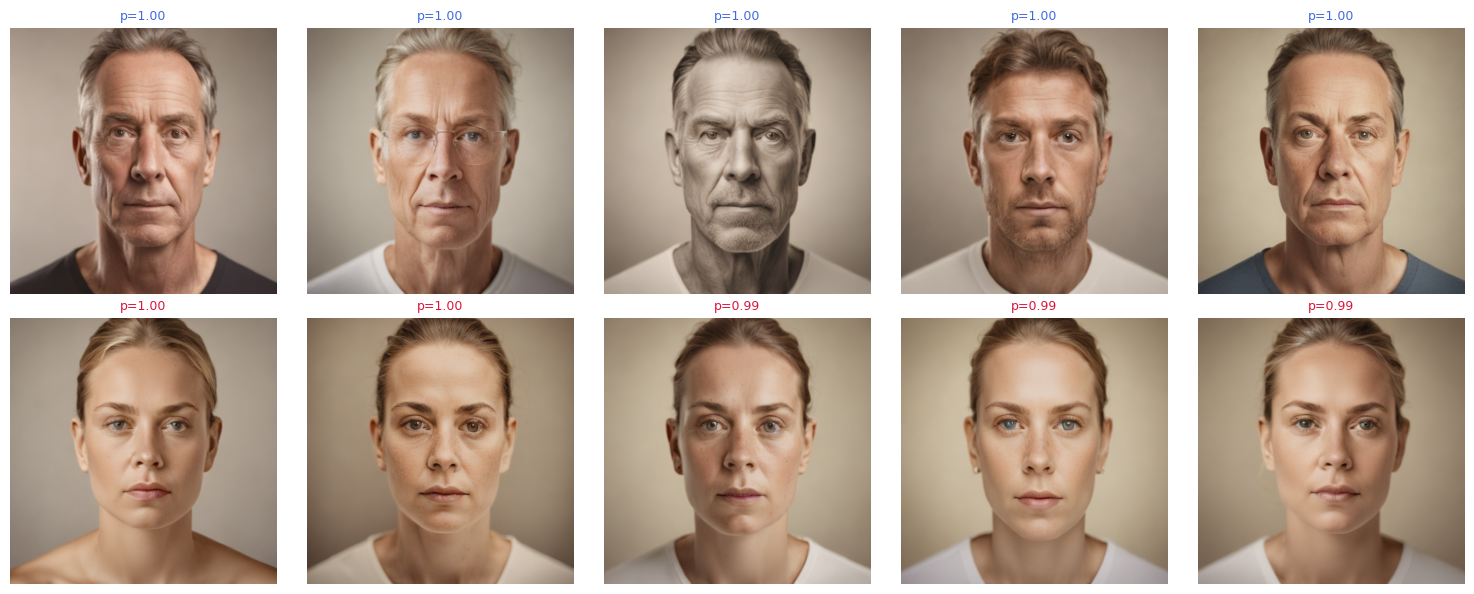

In [34]:

results_1, eval_clip_np_1 = compute_clip_softmax(eval_photos_1, clip_model, clip_processor, MAN_PROMPT, WOMAN_PROMPT, device)

for label, photos, results, mmd_val in [
    ("LGD-CM",  eval_photos_1, results_1, mmd_1),
]:
    n_male   = sum(1 for r in results if r["label"] == "male")
    n_female = sum(1 for r in results if r["label"] == "female")
    print(f"{label} — Male: {n_male}  Female: {n_female}  MMD: {mmd_val:.4f}")

    paired    = list(zip(photos, results))
    top_men   = sorted([(i, r) for i, r in paired if r["label"] == "male"],   key=lambda x: x[1]["p_male"],   reverse=True)[:5]
    top_women = sorted([(i, r) for i, r in paired if r["label"] == "female"], key=lambda x: x[1]["p_female"], reverse=True)[:5]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for col, (img, r) in enumerate(top_men):
        axes[0, col].imshow(img)
        axes[0, col].set_title(f'p={r["p_male"]:.2f}', fontsize=9, color='royalblue')
        axes[0, col].axis('off')
    for col in range(len(top_men), 5):
        axes[0, col].axis('off')
    for col, (img, r) in enumerate(top_women):
        axes[1, col].imshow(img)
        axes[1, col].set_title(f'p={r["p_female"]:.2f}', fontsize=9, color='crimson')
        axes[1, col].axis('off')
    for col in range(len(top_women), 5):
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('Top 5 Men',   fontsize=11, color='royalblue', labelpad=8)
    axes[1, 0].set_ylabel('Top 5 Women', fontsize=11, color='crimson',   labelpad=8)
    plt.tight_layout(); display(fig); plt.close()


### 10. CLIP t-SNE — Eval vs Target

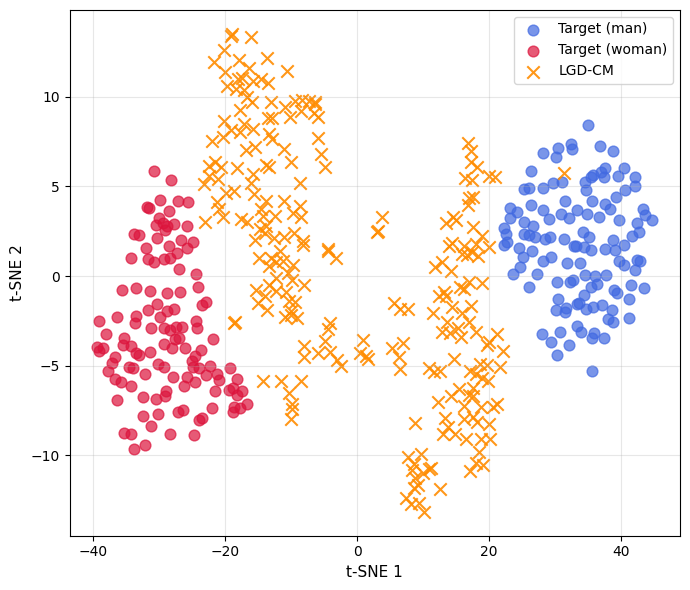

In [35]:
from sklearn.manifold import TSNE
from matplotlib.patches import Patch

target_np = all_clip_embeddings.cpu().numpy()

# Fit t-SNE on all points together (t-SNE has no transform, must fit all at once)
combined  = np.vstack([target_np, eval_clip_np_1])
labels    = (
    ["Target (man)"]   * n_half +
    ["Target (woman)"] * n_half +
    ["LGD-CM"]         * len(eval_clip_np_1)
)

tsne   = TSNE(n_components=2, random_state=GLOBAL_SEED, perplexity=30)
coords = tsne.fit_transform(combined)

t_man    = coords[:n_half]
t_woman  = coords[n_half:2*n_half]
e1_coords = coords[2*n_half:]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(t_man[:,0],    t_man[:,1],    c='royalblue', s=60, alpha=0.7, label='Target (man)')
ax.scatter(t_woman[:,0],  t_woman[:,1],  c='crimson',   s=60, alpha=0.7, label='Target (woman)')
ax.scatter(e1_coords[:,0],e1_coords[:,1],c='darkorange', s=80, alpha=0.9, marker='x', label='LGD-CM')
ax.set_xlabel('t-SNE 1', fontsize=11)
ax.set_ylabel('t-SNE 2', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

### 11. CLIP PCA — Eval vs Target

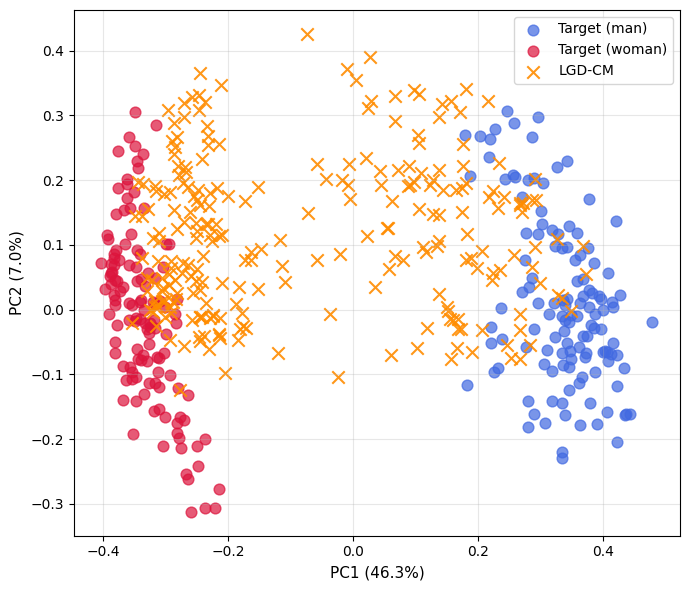

In [37]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

target_np = all_clip_embeddings.cpu().numpy()

# Fit PCA on target only, then project everything
pca      = PCA(n_components=2)
t_coords = pca.fit_transform(target_np)
e1_coords = pca.transform(eval_clip_np_1)

t_man   = t_coords[:n_half]
t_woman = t_coords[n_half:2*n_half]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(t_man[:,0],   t_man[:,1],   c='royalblue', s=60, alpha=0.7, label='Target (man)')
ax.scatter(t_woman[:,0], t_woman[:,1], c='crimson',   s=60, alpha=0.7, label='Target (woman)')
ax.scatter(e1_coords[:,0], e1_coords[:,1], c='darkorange', s=80, alpha=0.9, marker='x', label='LGD-CM')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

### 12. Boxplot

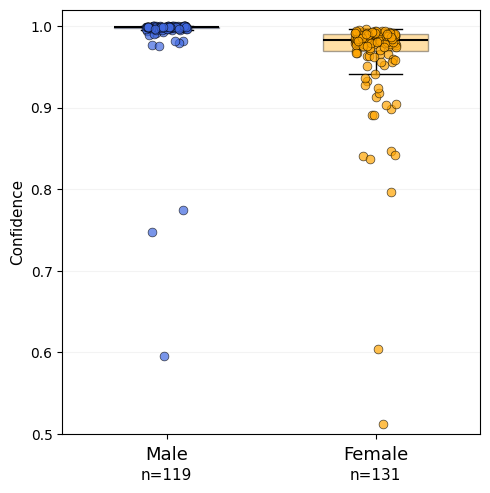

In [36]:
def split_conf(results):
    return (
        [r["p_male"]   for r in results if r["label"] == "male"],
        [r["p_female"] for r in results if r["label"] == "female"],
    )

m1, f1 = split_conf(results_1)

positions = [1, 2]
data      = [m1, f1]
colors    = ["royalblue", "orange"]

fig, ax = plt.subplots(figsize=(5, 5))
for pts, pos, col in zip(data, positions, colors):
    if pts:
        ax.boxplot(pts, positions=[pos], patch_artist=True, widths=0.5, showfliers=False,
                   medianprops=dict(color="black", linewidth=1.5),
                   boxprops=dict(facecolor=col, alpha=0.35, edgecolor="black"))
        jitter = np.random.uniform(-0.1, 0.1, size=len(pts))
        ax.scatter(np.full(len(pts), pos) + jitter, pts,
                   color=col, alpha=0.7, s=40, zorder=3, edgecolors="black", linewidth=0.5)

for pos, count in zip(positions, [len(m1), len(f1)]):
    ax.text(pos, -0.08, f"n={count}", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=11)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Male", "Female"], fontsize=13)
ax.tick_params(axis="x", pad=5)  # more padding so n= doesn't overlap
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Confidence", fontsize=11)
ax.grid(True, alpha=0.15, axis="y")
plt.tight_layout(); display(fig); plt.close()